**Task 2 : Decision Trees for Human Activity Recognition**

In [1]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

#### Note: We have combined the Q1) and Q2) for all the three parts below

1.Use Sklearn Library to train Decision Tress.

2.Train Decision Tree with varying depths (2-8) using all above 3 methods. Plot the accuracy of the model on test data vs the depth of the tree.

Note: We have done Q1 and Q2 together for all the three parts

a) Train a decision tree model using the raw accelerometer data. Report the accuracy, precision, recall and confusion matrix of the model.

In [2]:
df_train = pd.read_csv('df_train_2a.csv')
df_test = pd.read_csv('df_test_2a.csv')

In [3]:
df_train.head()

,0,1,2,3,4,5,6,7,8,9,...,490,491,492,493,494,495,496,497,498,499
0,0.848709,0.760164,0.736452,0.748299,0.782848,0.882488,0.958099,0.948714,0.930530,1.003035,...,1.353846,1.326801,1.187265,1.123056,1.044983,0.967130,0.955721,0.940260,0.937370,0.920635
1,0.994932,0.996157,0.997569,0.997141,0.997321,0.995469,0.992603,0.992008,0.996622,1.002989,...,0.996362,1.002647,1.001718,0.996088,0.993776,0.995001,0.995938,0.994459,0.993726,0.994293
2,1.029484,1.027762,1.025952,1.027855,1.029590,1.028772,1.028514,1.025848,1.022338,1.023719,...,1.031729,1.027246,1.023730,1.026660,1.031017,1.030908,1.028934,1.028393,1.028763,1.029616
3,0.873025,0.798615,0.727831,0.681650,0.624199,0.572181,0.627781,0.718508,0.835183,0.959438,...,0.555627,0.549743,0.622078,0.725444,0.821024,0.884565,1.006113,1.119521,1.068676,1.044513
4,0.782344,0.669613,0.622582,0.578245,0.551131,0.594676,0.689110,0.823618,0.891847,0.933120,...,0.581406,0.637681,0.662929,0.757451,0.920345,1.067191,1.129631,1.174664,1.338582,1.426424


In [4]:
df_test.head()

,0,1,2,3,4,5,6,7,8,9,...,490,491,492,493,494,495,496,497,498,499
0,1.315677,1.604243,1.830893,1.898958,1.827327,1.620880,1.316908,1.170661,1.052928,0.754885,...,1.764761,1.639306,1.523885,1.416439,1.240125,1.087496,0.893483,0.738629,0.721044,0.631276
1,1.054856,1.136392,1.156623,1.144792,1.157303,1.256707,1.373923,1.357964,1.260566,1.143371,...,0.922238,0.988027,1.003726,1.025643,1.101458,1.162664,1.131585,1.101898,1.127893,1.159806
2,1.066860,1.057793,1.005084,0.953131,0.936750,0.894240,0.869101,0.777311,0.631513,0.622790,...,1.063830,1.100856,1.181338,1.254771,1.336512,1.414291,1.470916,1.593582,1.656637,1.481759
3,1.036042,1.036788,1.029928,1.022799,1.027641,1.036674,1.035558,1.031314,1.025582,1.022758,...,1.033032,1.029915,1.026137,1.028114,1.028717,1.029478,1.030757,1.028273,1.026989,1.028143
4,1.033301,1.032317,1.032423,1.033606,1.031874,1.029899,1.030803,1.033281,1.034185,1.032604,...,1.035920,1.030554,1.025169,1.030608,1.036265,1.037410,1.038579,1.038102,1.036806,1.033834


In [5]:
from MakeDataset import y_train, y_test

Training data shape:  (126, 500, 3)
Testing data shape:  (54, 500, 3)


In [6]:
clf = DecisionTreeClassifier(random_state=42)

clf.fit(df_train, y_train)

y_pred = clf.predict(df_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')

conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print("Confusion Matrix:")
print(conf_matrix)

Accuracy: 0.50
Precision: 0.48
Recall: 0.50
Confusion Matrix:
[[4 3 1 0 0 1]
 [4 2 2 0 1 0]
 [6 2 1 0 0 0]
 [0 0 0 6 2 1]
 [0 0 0 2 7 0]
 [0 0 0 2 0 7]]


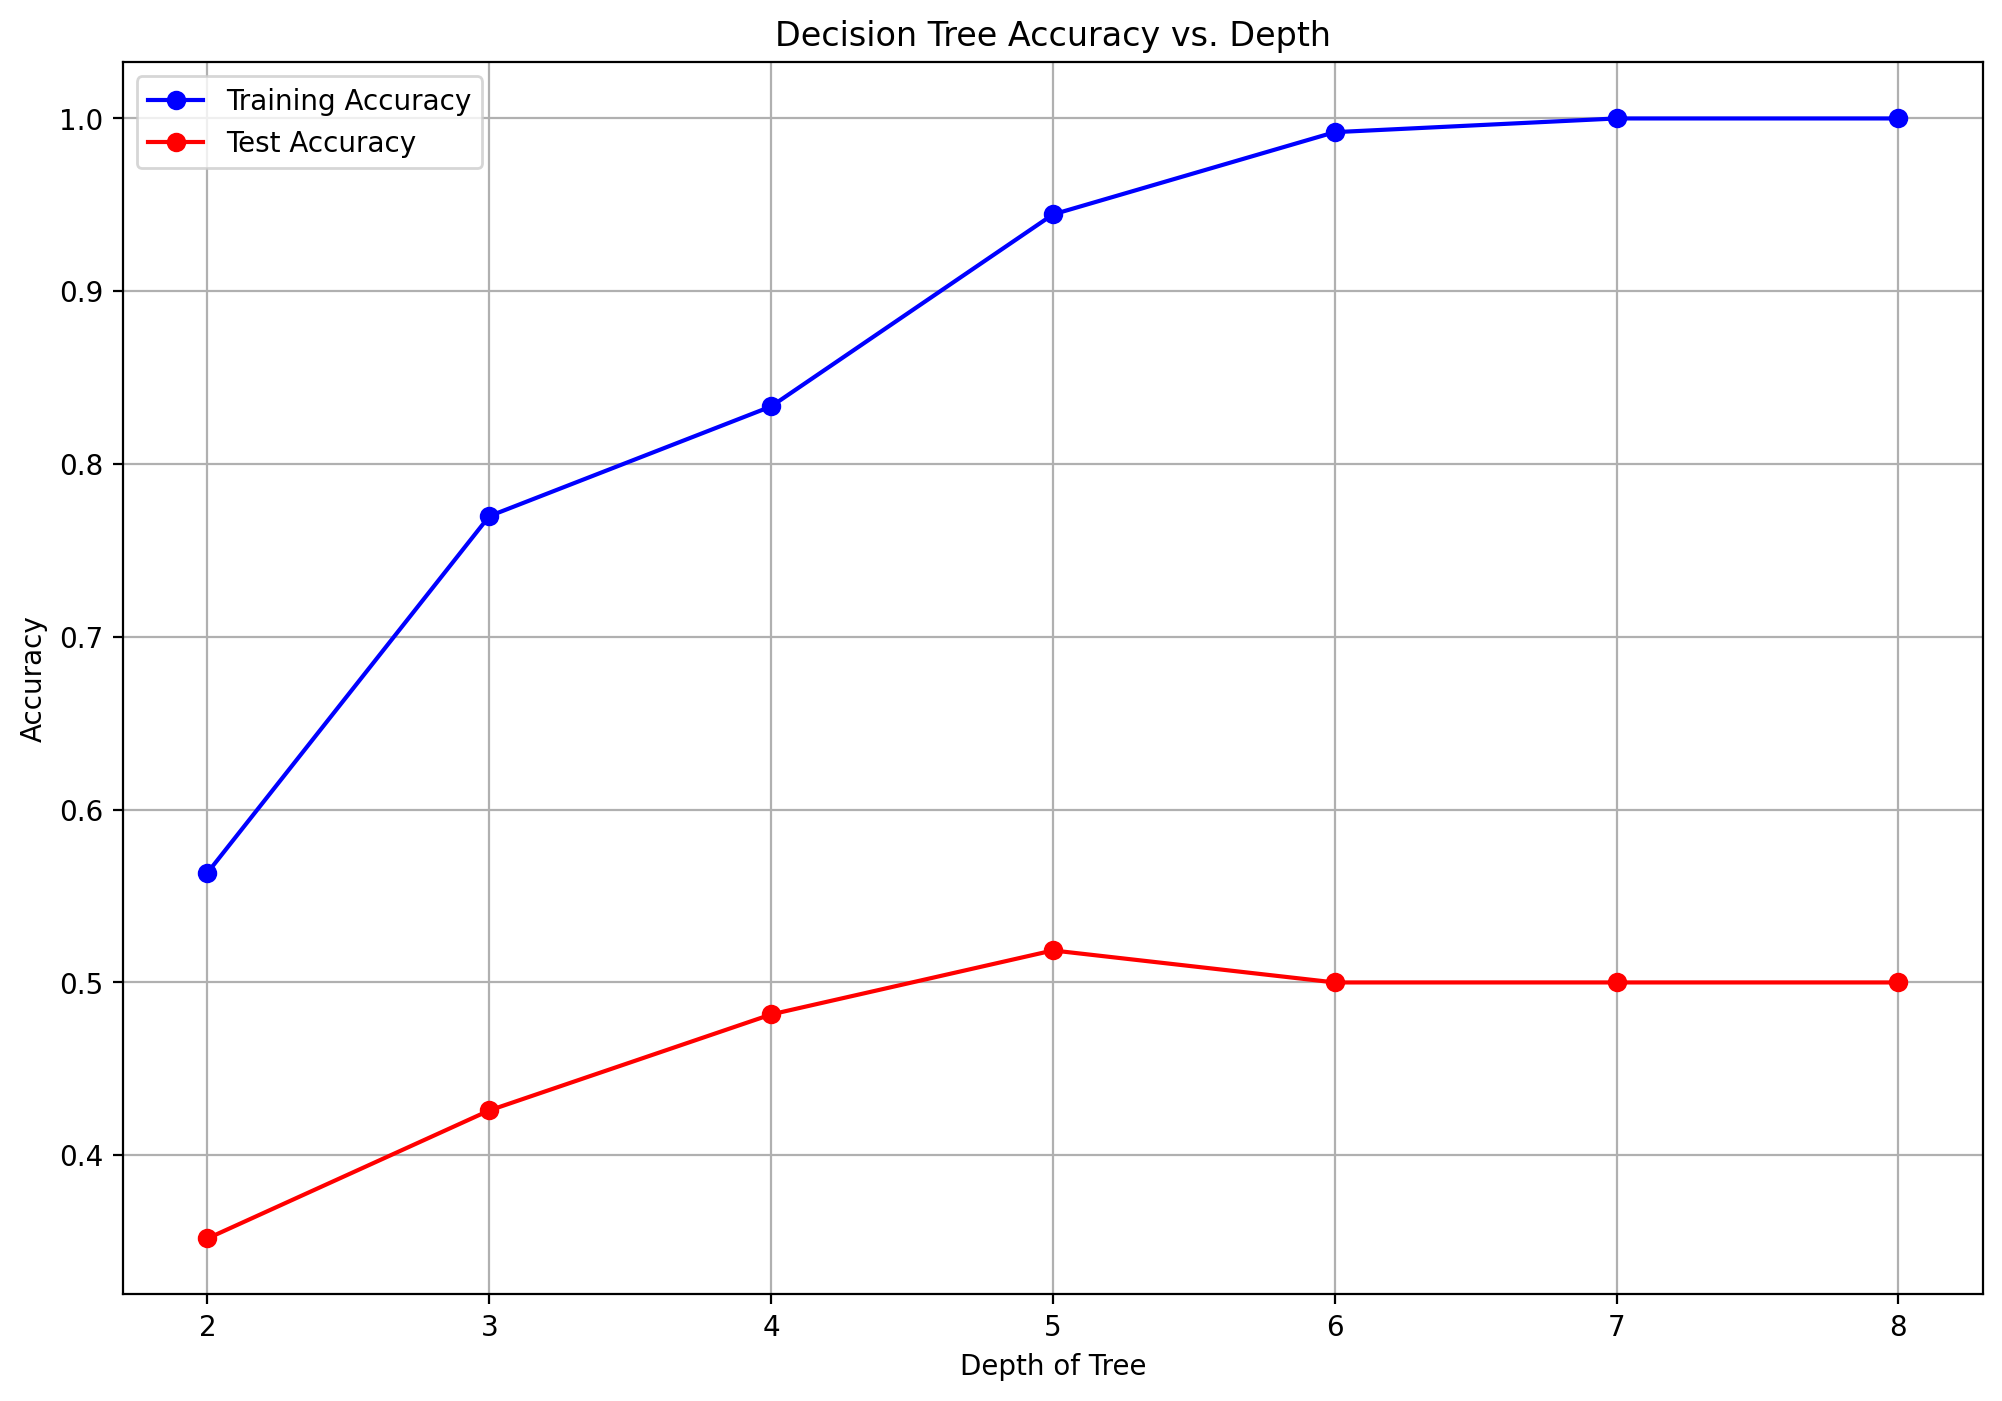

In [7]:
depths = range(2, 9)
train_accuracies = []
test_accuracies = []

for depth in depths:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf.fit(df_train, y_train)

    train_accuracy = clf.score(df_train, y_train)
    train_accuracies.append(train_accuracy)

    test_accuracy = clf.score(df_test, y_test)
    test_accuracies.append(test_accuracy)

plt.figure(figsize=(12, 8))
plt.plot(depths, train_accuracies, marker='o', linestyle='-', color='b', label='Training Accuracy')
plt.plot(depths, test_accuracies, marker='o', linestyle='-', color='r', label='Test Accuracy')
plt.xlabel('Depth of Tree')
plt.ylabel('Accuracy')
plt.title('Decision Tree Accuracy vs. Depth')
plt.xticks(depths)
plt.grid(True)
plt.legend()
plt.show()

b) Train a decision tree model using the features obtained by TSFEL. Report the accuracy, precision, recall and confusion matrix of the model.

In [8]:
tsfel_x_train = pd.read_csv('tsfel_x_train.csv')
tsfel_x_test = pd.read_csv('tsfel_x_test.csv')

In [9]:
tsfel_x_train

,0_Absolute energy,0_Area under the curve,0_Autocorrelation,0_Average power,0_Centroid,0_ECDF Percentile Count_0,0_ECDF Percentile Count_1,0_ECDF Percentile_0,0_ECDF Percentile_1,0_ECDF_0,...,2_Wavelet variance_12.5Hz,2_Wavelet variance_2.78Hz,2_Wavelet variance_25.0Hz,2_Wavelet variance_3.12Hz,2_Wavelet variance_3.57Hz,2_Wavelet variance_4.17Hz,2_Wavelet variance_5.0Hz,2_Wavelet variance_6.25Hz,2_Wavelet variance_8.33Hz,2_Zero crossing rate
0,501.232235,4.888430,5.0,100.447342,2.491203,100.0,400.0,0.794262,1.161621,0.002,...,0.010100,0.348718,0.002086,0.270165,0.199318,0.137104,0.086903,0.048801,0.023596,20.0
1,14.915826,0.861314,5.0,2.989144,2.445587,100.0,400.0,0.167716,0.178158,0.002,...,0.003447,0.065658,0.000873,0.052301,0.040457,0.029877,0.020914,0.013438,0.007573,0.0
2,472.613637,4.851288,2.0,94.712152,2.489768,100.0,400.0,0.969142,0.976063,0.002,...,0.000548,0.009158,0.000132,0.007328,0.005687,0.004205,0.002949,0.001924,0.001140,0.0
3,530.780991,4.987810,5.0,106.368936,2.486213,100.0,400.0,0.770850,1.138045,0.002,...,0.009039,0.107854,0.001977,0.096213,0.078936,0.058920,0.040878,0.026905,0.016773,44.0
4,535.203126,4.909927,5.0,107.255136,2.523841,100.0,400.0,0.677298,1.228880,0.002,...,0.004363,0.069302,0.001027,0.057609,0.046116,0.034577,0.024373,0.016441,0.009867,45.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121,536.288734,5.023866,3.0,107.472692,2.490408,100.0,400.0,0.781321,1.240025,0.002,...,0.019554,0.213206,0.006074,0.184391,0.153465,0.117265,0.080422,0.049952,0.030524,61.0
122,516.593019,5.072112,2.0,103.525655,2.495133,100.0,400.0,1.014998,1.018187,0.002,...,0.000113,0.001200,0.000030,0.000969,0.000769,0.000593,0.000442,0.000310,0.000199,0.0
123,26.634599,0.938141,129.0,5.337595,1.349603,100.0,400.0,-0.324844,0.038536,0.002,...,0.002028,0.039413,0.000479,0.030635,0.023129,0.016746,0.011650,0.007645,0.004476,3.0
124,525.997480,4.991561,4.0,105.410317,2.532697,100.0,400.0,0.824270,1.190775,0.002,...,0.013109,0.125085,0.002726,0.128233,0.120569,0.102884,0.079850,0.054590,0.030384,16.0


In [10]:
tsfel_x_test.head()

,0_Absolute energy,0_Area under the curve,0_Autocorrelation,0_Average power,0_Centroid,0_ECDF Percentile Count_0,0_ECDF Percentile Count_1,0_ECDF Percentile_0,0_ECDF Percentile_1,0_ECDF_0,...,2_Wavelet variance_12.5Hz,2_Wavelet variance_2.78Hz,2_Wavelet variance_25.0Hz,2_Wavelet variance_3.12Hz,2_Wavelet variance_3.57Hz,2_Wavelet variance_4.17Hz,2_Wavelet variance_5.0Hz,2_Wavelet variance_6.25Hz,2_Wavelet variance_8.33Hz,2_Zero crossing rate
0,595.590421,5.064457,5.0,119.356798,2.491319,100.0,400.0,0.683207,1.432725,0.002,...,0.044346,0.041650,0.009942,0.041302,0.040073,0.038546,0.040035,0.045468,0.049908,42.0
1,529.914938,5.024143,4.0,106.195378,2.475981,100.0,400.0,0.842492,1.213160,0.002,...,0.004799,0.067730,0.001539,0.058356,0.048385,0.036621,0.024350,0.014150,0.008051,30.0
2,527.866197,5.002506,6.0,105.784809,2.520863,100.0,400.0,0.826546,1.130707,0.002,...,0.004742,0.079033,0.001199,0.059702,0.042853,0.029269,0.019676,0.013162,0.008584,63.0
3,525.766114,5.116533,2.0,105.363951,2.496264,100.0,400.0,1.022367,1.028935,0.002,...,0.000310,0.003145,0.000074,0.002203,0.001537,0.001090,0.000822,0.000661,0.000506,22.0
4,518.476061,5.081227,3.0,103.903018,2.493970,100.0,400.0,1.016041,1.020592,0.002,...,0.000089,0.001303,0.000021,0.000991,0.000738,0.000533,0.000376,0.000259,0.000170,0.0


In [11]:
clf_tsfel = DecisionTreeClassifier(random_state=42)

clf_tsfel.fit(tsfel_x_train, y_train)

y_pred = clf_tsfel.predict(tsfel_x_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print("Confusion Matrix:")
print(conf_matrix)

Accuracy: 0.8703703703703703
Precision: 0.8732022607022607
Recall: 0.8703703703703703
Confusion Matrix:
[[8 0 1 0 0 0]
 [0 9 0 0 0 0]
 [1 2 6 0 0 0]
 [0 0 0 7 2 0]
 [0 0 0 1 8 0]
 [0 0 0 0 0 9]]


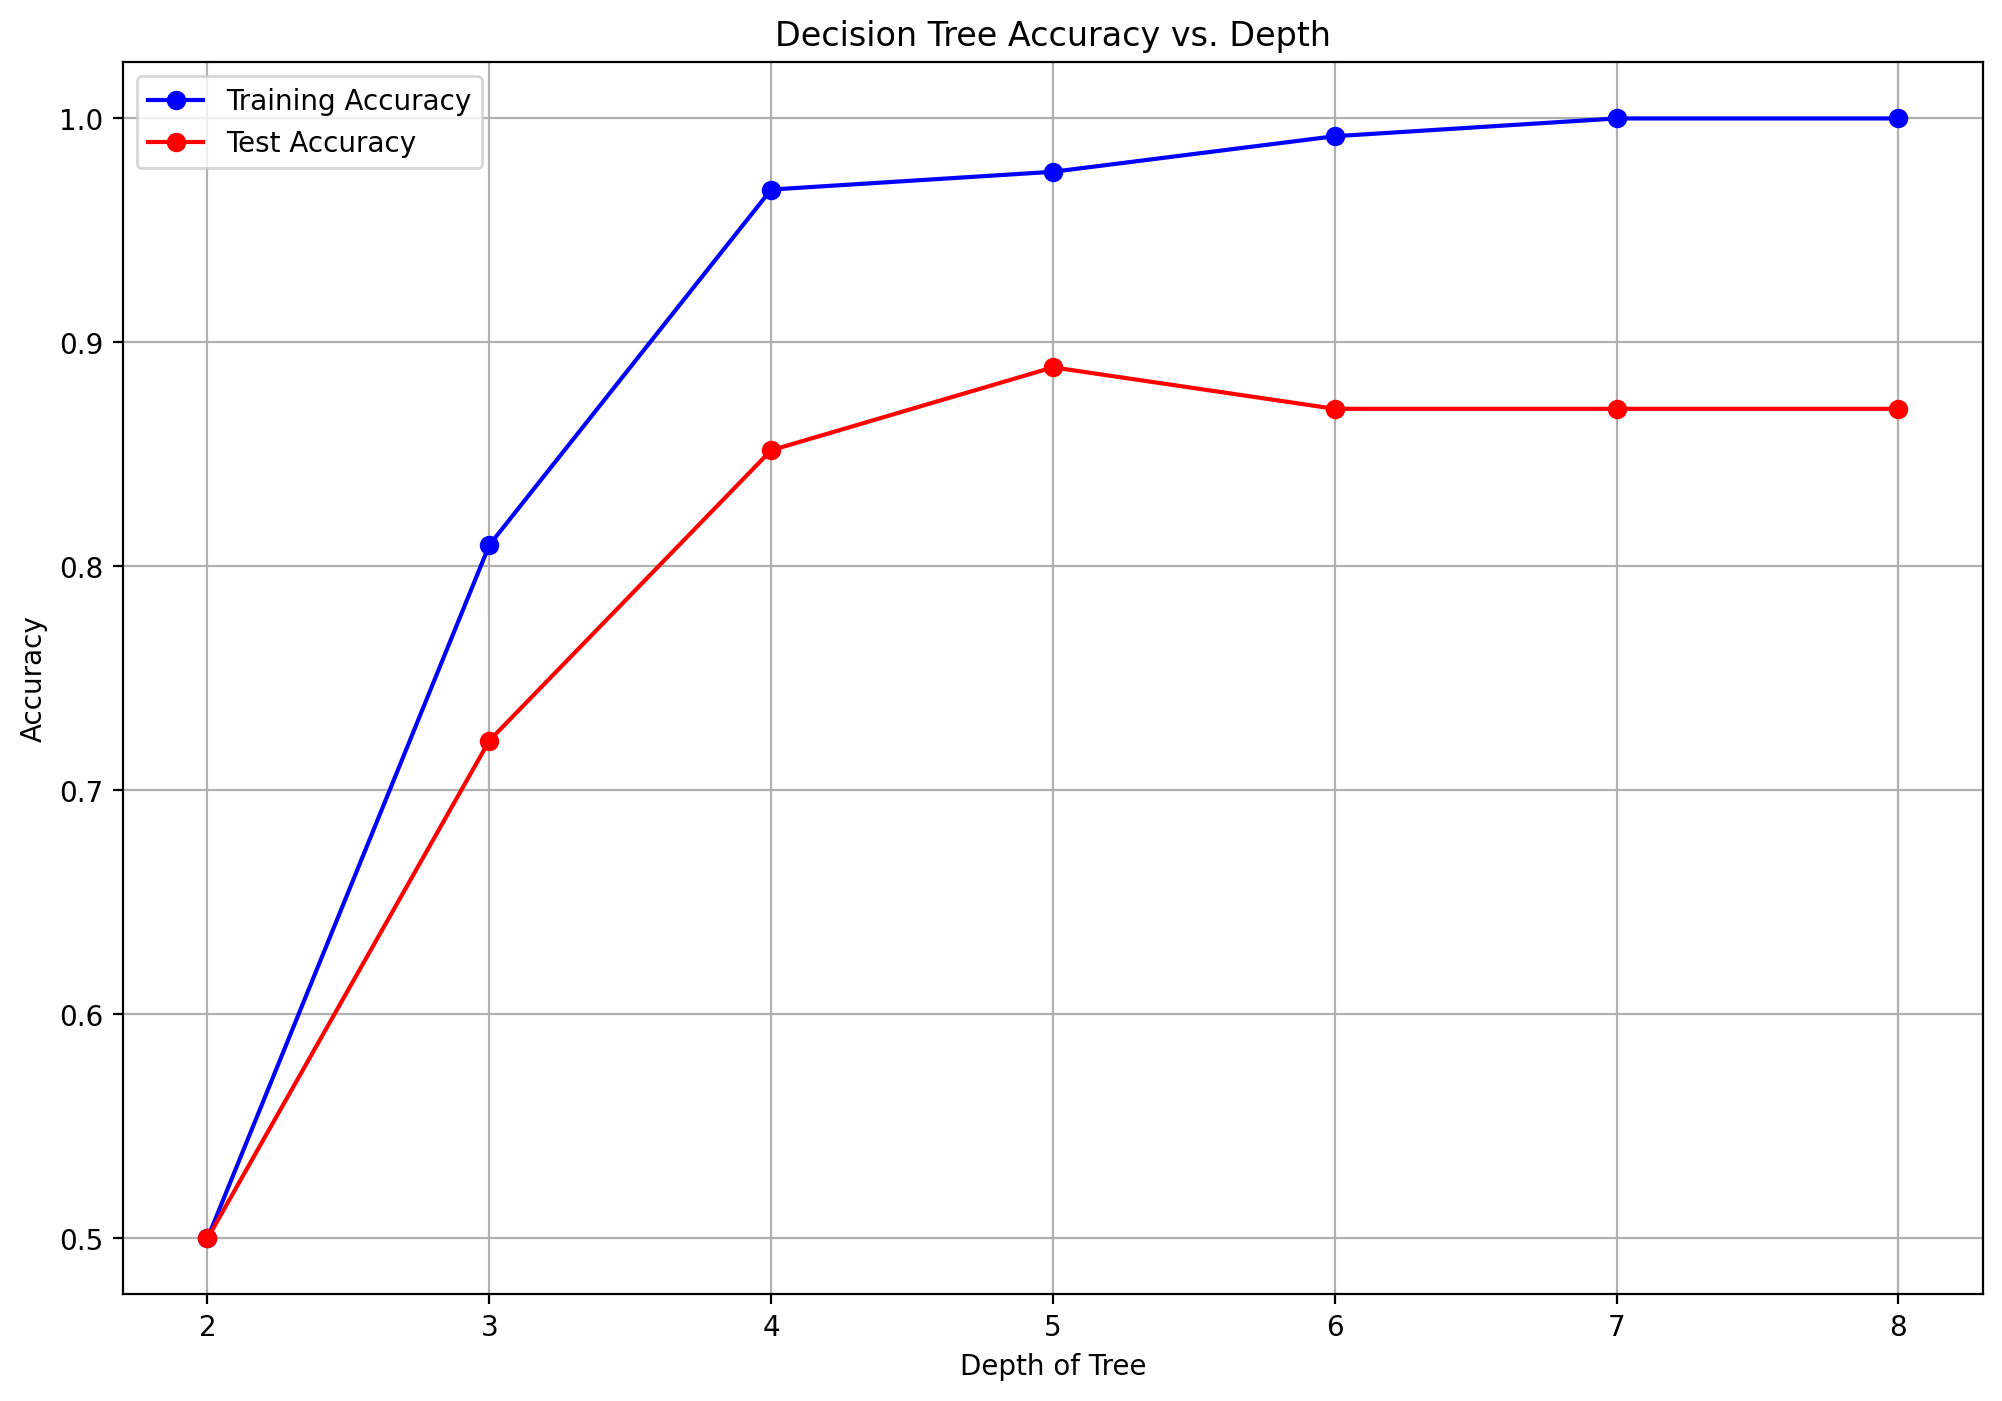

In [12]:
depths = range(2, 9)
train_accuracies = []
test_accuracies = []

for depth in depths:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf.fit(tsfel_x_train, y_train)

    train_accuracy = clf.score(tsfel_x_train, y_train)
    train_accuracies.append(train_accuracy)

    test_accuracy = clf.score(tsfel_x_test, y_test)
    test_accuracies.append(test_accuracy)

plt.figure(figsize=(12, 8))
plt.plot(depths, train_accuracies, marker='o', linestyle='-', color='b', label='Training Accuracy')
plt.plot(depths, test_accuracies, marker='o', linestyle='-', color='r', label='Test Accuracy')
plt.xlabel('Depth of Tree')
plt.ylabel('Accuracy')
plt.title('Decision Tree Accuracy vs. Depth')
plt.xticks(depths)
plt.grid(True)
plt.legend()
plt.show()

c) Train a decision tree model using the features provided in the dataset. Report the accuracy, precision, recall and confusion matrix of the model.

In [13]:
X_train_featurized = pd.read_csv("./UCI HAR Dataset/train/X_train.txt", delim_whitespace=True, header=None)
Y_train_featurized = pd.read_csv("./UCI HAR Dataset/train/y_train.txt", delim_whitespace=True, header=None)

X_test_featurized = pd.read_csv("./UCI HAR Dataset/test/X_test.txt", delim_whitespace=True, header=None)
Y_test_featurized = pd.read_csv("./UCI HAR Dataset/test/y_test.txt", delim_whitespace=True, header=None)

clf = DecisionTreeClassifier(random_state=42)

clf.fit(X_train_featurized, Y_train_featurized)

y_pred = clf.predict(X_test_featurized)

accuracy = accuracy_score(Y_test_featurized, y_pred)
precision = precision_score(Y_test_featurized, y_pred, average='weighted')
recall = recall_score(Y_test_featurized, y_pred, average='weighted')
conf_matrix = confusion_matrix(Y_test_featurized, y_pred)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print("Confusion Matrix:")
print(conf_matrix)

/tmp/ipykernel_154757/861188613.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_train_featurized = pd.read_csv("./UCI HAR Dataset/train/X_train.txt", delim_whitespace=True, header=None)
/tmp/ipykernel_154757/861188613.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  Y_train_featurized = pd.read_csv("./UCI HAR Dataset/train/y_train.txt", delim_whitespace=True, header=None)
/tmp/ipykernel_154757/861188613.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_test_featurized = pd.read_csv("./UCI HAR Dataset/test/X_test.txt", delim_whitespace=True, header=None)
/tmp/ipykernel_154757/861188613.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed 

Accuracy: 0.8622327790973872
Precision: 0.8632726592620287
Recall: 0.8622327790973872
Confusion Matrix:
[[456  24  16   0   0   0]
 [ 74 369  28   0   0   0]
 [ 19  53 348   0   0   0]
 [  0   0   0 374 117   0]
 [  0   0   0  75 457   0]
 [  0   0   0   0   0 537]]


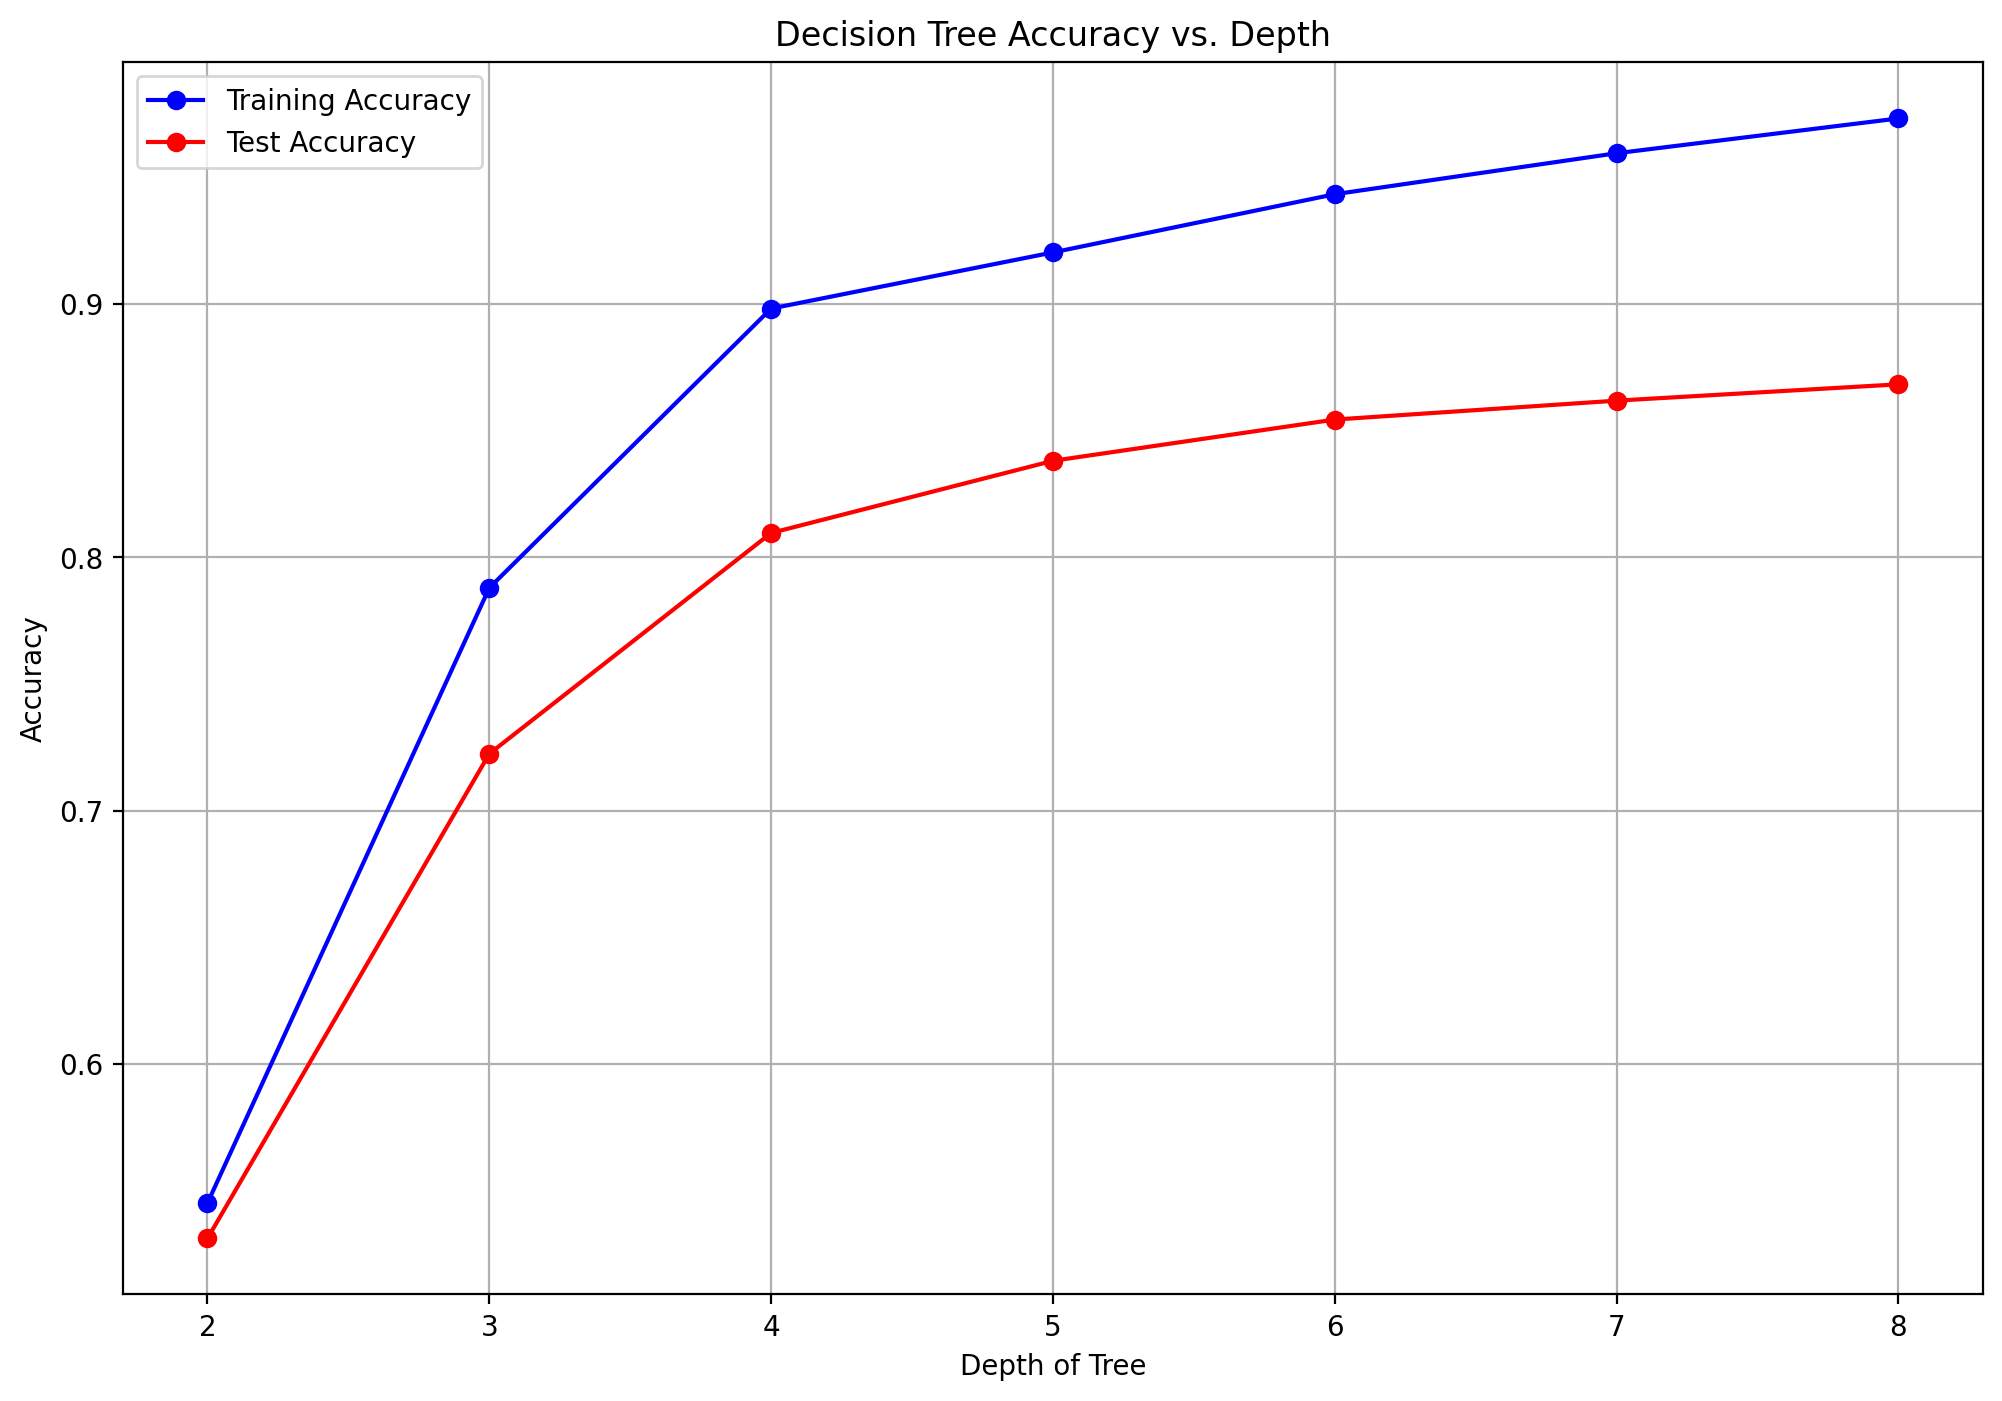

In [14]:
depths = range(2, 9)
train_accuracies = []
test_accuracies = []

for depth in depths:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf.fit(X_train_featurized, Y_train_featurized)

    train_accuracy = clf.score(X_train_featurized, Y_train_featurized)
    train_accuracies.append(train_accuracy)

    test_accuracy = clf.score(X_test_featurized, Y_test_featurized)
    test_accuracies.append(test_accuracy)

plt.figure(figsize=(12, 8))
plt.plot(depths, train_accuracies, marker='o', linestyle='-', color='b', label='Training Accuracy')
plt.plot(depths, test_accuracies, marker='o', linestyle='-', color='r', label='Test Accuracy')
plt.xlabel('Depth of Tree')
plt.ylabel('Accuracy')
plt.title('Decision Tree Accuracy vs. Depth')
plt.xticks(depths)
plt.grid(True)
plt.legend()
plt.show()

d) Compare the results of the three models. Which model do you think is better?

We are getting 65% accuracy with the raw accelorometer, 89% with the features obtained by TSFEL and 86% with the features provided in the dataset. Along with accuracy, even the precsion and recall of the TSFEL features are the highest. Thus we can say that the features obtained by TSFEL are performing better.

3.Are there any participants/ activitivies where the Model performace is bad? If Yes, Why? 

In [15]:
from sklearn.metrics import classification_report

y_pred = clf_tsfel.predict(tsfel_x_test)

activity_labels = ['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS']

report = classification_report(y_test, y_pred, target_names=activity_labels, output_dict=True)

for activity, metrics in report.items():
    if activity != 'accuracy':
        print(f"Metrics for {activity}:")
        print(f"  Precision: {metrics['precision']:.2f}")
        print(f"  Recall: {metrics['recall']:.2f}")
        print(f"  F1-score: {metrics['f1-score']:.2f}")
        print()


Metrics for LAYING:
  Precision: 0.89
  Recall: 0.89
  F1-score: 0.89

Metrics for SITTING:
  Precision: 0.82
  Recall: 1.00
  F1-score: 0.90

Metrics for STANDING:
  Precision: 0.86
  Recall: 0.67
  F1-score: 0.75

Metrics for WALKING:
  Precision: 0.88
  Recall: 0.78
  F1-score: 0.82

Metrics for WALKING_UPSTAIRS:
  Precision: 0.80
  Recall: 0.89
  F1-score: 0.84

Metrics for WALKING_DOWNSTAIRS:
  Precision: 1.00
  Recall: 1.00
  F1-score: 1.00

Metrics for macro avg:
  Precision: 0.87
  Recall: 0.87
  F1-score: 0.87

Metrics for weighted avg:
  Precision: 0.87
  Recall: 0.87
  F1-score: 0.87



We can see that the F1 score for Laying is 0.75, Standing is 0.78 and 0.80 for Sitting. Our tsfel model is performing on bad on these static activities. It is performing quite well on the dynamic activities such as Walking, Walking_Upstairs and Walking_Downstairs